In [5]:
import sys                                                                             
sys.path.insert(0, "..")
                                                                                         
from spz_dmh_sim import run, STATE_NAMES                                       
import matplotlib.pyplot as plt
import numpy as np                                                                     
from src.currents import I_circadian
from scipy.signal import find_peaks

                                                                                       
%matplotlib inline
                                                                                       
res = run(duration_h=24.0)

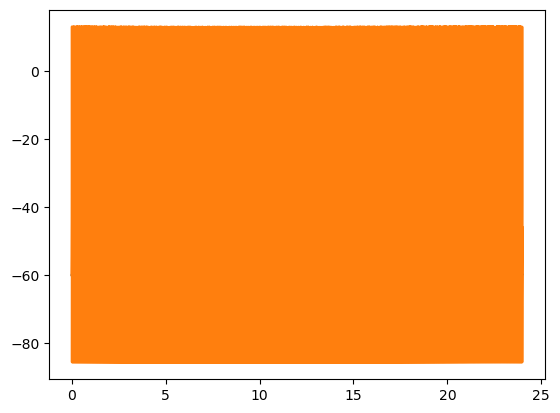

In [6]:
plt.plot(res.t_h, res.D)
plt.plot(res.t_h, res.S)

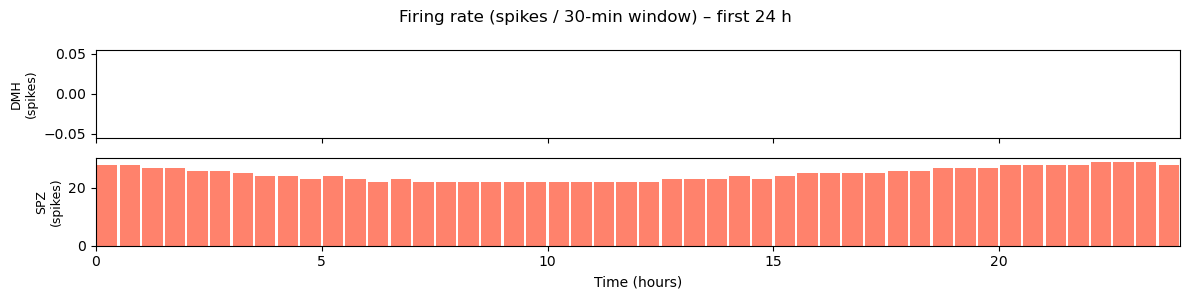

In [9]:
def plot_spike_counts(
    res,
    t0: float = 0.0,
    tf: float = 72.0,
    window_h: float = 0.5,
    peak_height: float = 0.0,
    peak_distance: int = 10,
) -> plt.Figure:
    edges   = np.arange(t0, tf + window_h, window_h)
    centers = (edges[:-1] + edges[1:]) / 2

    def _count(voltage):
        counts = []
        for i in range(len(edges) - 1):
            t0 = edges[i]     * 3600.0
            t1 = edges[i + 1] * 3600.0
            seg = voltage[(res.t_s >= t0) & (res.t_s < t1)]
            if len(seg):
                pks, _ = find_peaks(seg, height=peak_height, distance=peak_distance)
                counts.append(len(pks))
            else:
                counts.append(0)
        return counts

    specs = [
        (_count(res.D), "DMH",  "steelblue"),
        (_count(res.S), "SPZ",  "tomato"),
    ]

    fig, axes = plt.subplots(2, 1, figsize=(12, 3), sharex=True)
    fig.suptitle(f"Firing rate (spikes / {window_h*60:.0f}-min window) – first {tf-t0:.0f} h",
                 fontsize=12)

    for ax, (counts, label, color) in zip(axes, specs):
        ax.bar(centers, counts, width=window_h * 0.9, color=color, alpha=0.8)
        ax.set_ylabel(f"{label}\n(spikes)", fontsize=9)

    axes[-1].set_xlabel("Time (hours)")
    axes[-1].set_xlim(t0, tf)
    plt.tight_layout()
    return fig

plot_spike_counts(res, 0, 24)
plt.show()